# Footprint Extraction — End to End

DINOv3 (SAT-493M) + LoRA + decoder, trained with PyTorch Lightning on 0.06 m satellite
tiles, using TorchGeo `GriddedPatchSampler` for patch extraction.

This notebook runs top to bottom on **`configs/smoke.yaml`** — one tile, a lightweight
CNN decoder, 2 epochs, 8 train / 4 val batches — so it finishes in a few minutes and
exercises the full pipeline: grid → split → dataset → model → training → evaluation.
For the real experiment, switch `CONFIG_PATH` below to `configs/default.yaml` (3 tiles,
DPT decoder, 100 epochs with early stopping) and expect it to run for hours on a GPU.

**Prerequisite**: `facebook/dinov3-vitl16-pretrain-sat493m` is a gated Hugging Face repo.
Request access, then run `uv run hf auth login` before this notebook downloads it.

In [1]:
CONFIG_PATH = "configs/default.yaml"   # switch to "configs/default.yaml" for the real run

In [2]:
import warnings
warnings.filterwarnings("ignore", message=".*LeafSpec.*")

## 1. Environment and device check

In [3]:
import sys
from pathlib import Path

# Jupyter starts with the notebook's own directory as the working directory, not the
# project root, so relative paths (configs/, FP_data/, outputs/) would otherwise break.
# Walk up from here until pyproject.toml is found and make that the working directory.
root = Path.cwd()
while not (root / "pyproject.toml").exists():
    if root == root.parent:
        raise RuntimeError("could not locate the project root (pyproject.toml)")
    root = root.parent

import os

os.chdir(root)
sys.path.insert(0, str(root / "src"))
print("project root:", root)

project root: c:\Data_Science\BuildingFootPrints


In [4]:
import torch
import lightning as L

print("python:", sys.version.split()[0])
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))

W0917 16:31:55.239000 20452 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


python: 3.13.15
torch: 2.11.0+cu128 | CUDA available: True
device: NVIDIA RTX PRO 4500 Blackwell


In [5]:
import subprocess

try:
    who = subprocess.run(["hf", "auth", "whoami"], capture_output=True, text=True, check=True)
    print(who.stdout.strip())
except Exception as exc:
    print(
        "Not logged in to Hugging Face, or `hf` is unavailable.\n"
        "DINOv3 SAT-493M is gated: request access on the model page, then run "
        "`uv run hf auth login`.\n"
        f"({exc})"
    )

âœ“ Logged in
  user: zubahme97


## 2. Inspect the source tiles

In [6]:
import rasterio

from fp.config import load_config

config = load_config(CONFIG_PATH)
data_cfg = config["data"]

for tile_id in data_cfg["tiles"]:
    path = Path(data_cfg["image_dir"]) / f"{tile_id}.tif"
    with rasterio.open(path) as src:
        print(f"{tile_id}: {src.width}x{src.height} px, {src.count} bands, "
              f"res={src.res}, crs={src.crs}")

image1: 9576x9564 px, 3 bands, res=(0.059999999999999845, 0.06), crs=EPSG:32644
image2: 9694x9332 px, 3 bands, res=(0.059999999999999845, 0.06), crs=EPSG:32644


## 3. Build the complete spatial grid

The full TorchGeo `GriddedPatchSampler` grid is generated for **every** tile before any
splitting (`src/fp/grid.py`). Edge cells that would read outside a tile's extent are
dropped.

In [7]:
from fp.config import set_seed
from fp.grid import build_grid

set_seed(config)
grid = build_grid(config)
print(f"{len(grid)} grid cells across {grid['tile_id'].nunique()} tile(s)")
grid.head()

Seed set to 42


578 grid cells across 2 tile(s)


,tile_id,grid_row,grid_col,minx,miny,maxx,maxy,geometry
0,image1,1,1,241511.91,1922219.04,241542.63,1922249.76,"POLYGON ((241542.63 1922219.04, 241542.63 1922..."
1,image1,1,2,241542.63,1922219.04,241573.35,1922249.76,"POLYGON ((241573.35 1922219.04, 241573.35 1922..."
2,image1,1,3,241573.35,1922219.04,241604.07,1922249.76,"POLYGON ((241604.07 1922219.04, 241604.07 1922..."
3,image1,1,4,241604.07,1922219.04,241634.79,1922249.76,"POLYGON ((241634.79 1922219.04, 241634.79 1922..."
4,image1,1,5,241634.79,1922219.04,241665.51,1922249.76,"POLYGON ((241665.51 1922219.04, 241665.51 1922..."


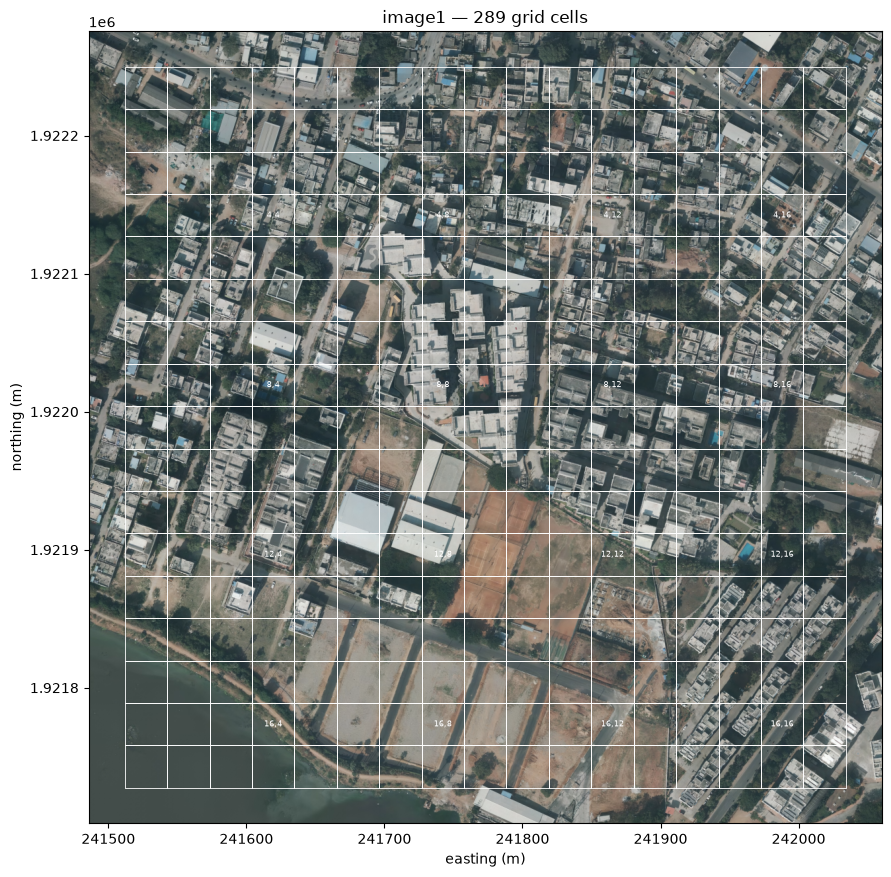

In [8]:
from fp.viz import plot_tile_grid

tile_id = data_cfg["tiles"][0]
image_path = Path(data_cfg["image_dir"]) / f"{tile_id}.tif"
fig = plot_tile_grid(grid, tile_id, image_path)

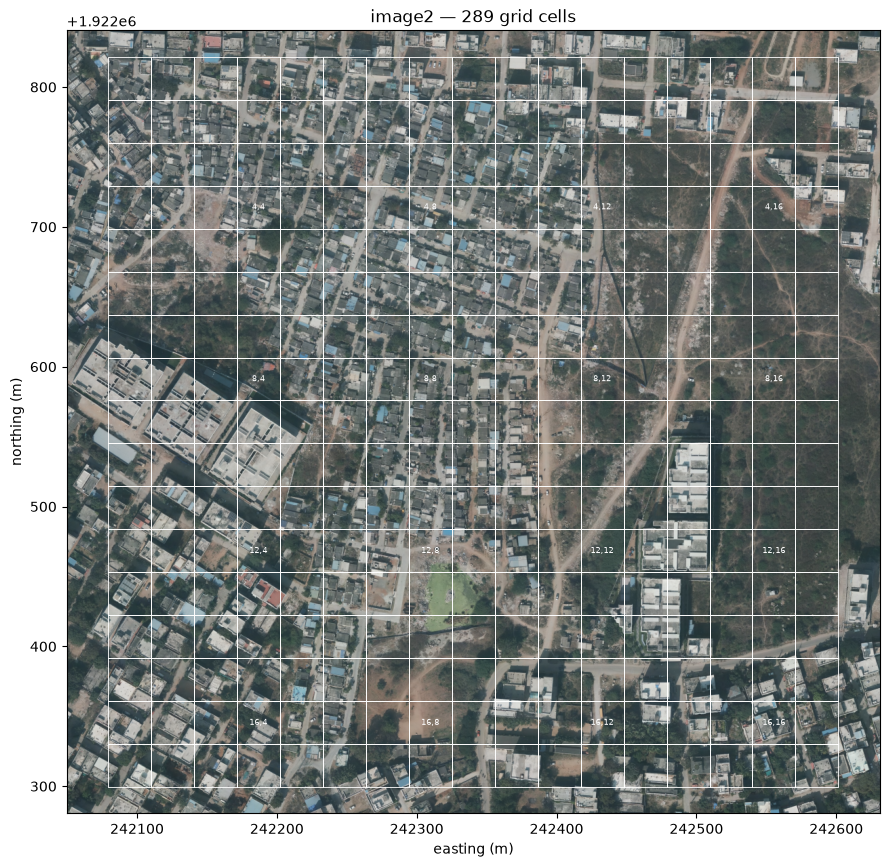

In [9]:
tile_id = data_cfg["tiles"][1]
image_path = Path(data_cfg["image_dir"]) / f"{tile_id}.tif"
fig = plot_tile_grid(grid, tile_id, image_path)

## 4. Split each tile's cells into train / validation / test

Splitting happens **within each tile independently** (`assign_splits`), so every tile
contributes to all three splits — the project's intended design (see `CLAUDE.md`). This
means nearby patches across splits can be spatially correlated; it is a deliberate,
documented trade-off, not an oversight.

In [10]:
from fp.grid import assign_splits, save_grid, split_counts

grid = assign_splits(grid, config)
save_grid(grid, data_cfg["grid_path"])
split_counts(grid)

split,train,val,test
tile_id,,,
image1,173,58,58
image2,173,58,58


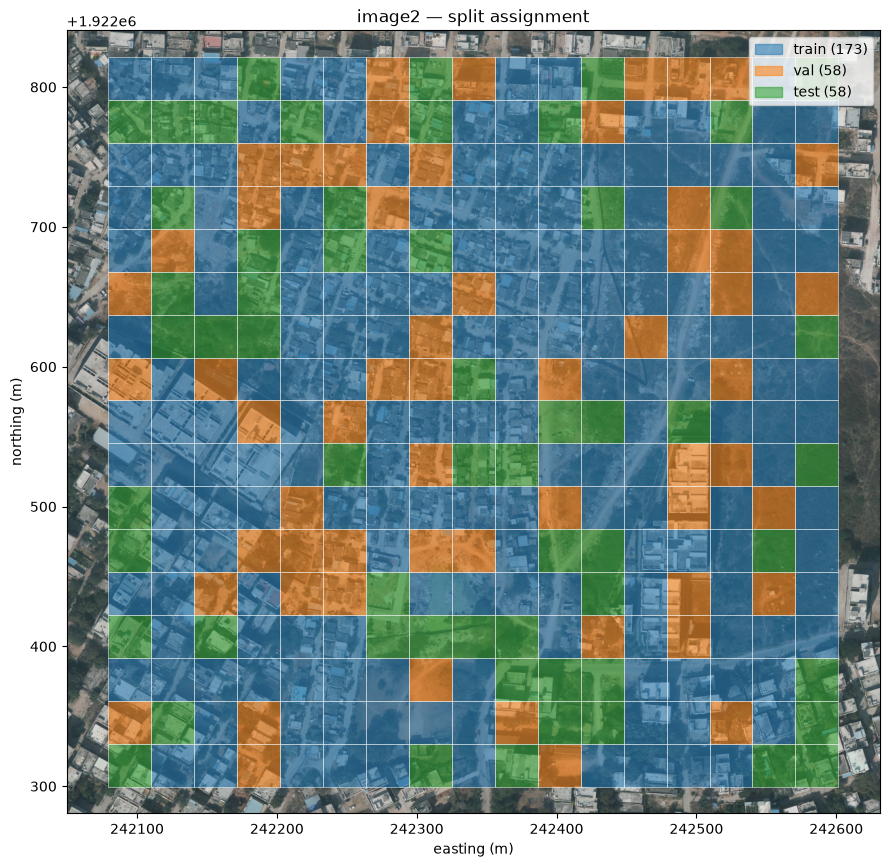

In [11]:
from fp.viz import plot_split_grid

fig = plot_split_grid(grid, tile_id, image_path)

## 5. Datasets and a sample patch

In [12]:
from fp.data import PatchDataset, build_dataloaders

loaders = build_dataloaders(grid, config)
train_dataset = PatchDataset(grid, config, "train", augmented=True)
val_dataset = PatchDataset(grid, config, "val", augmented=False)

print("train patches:", len(train_dataset), "| val patches:", len(val_dataset))

sample = val_dataset[0]
print("image:", sample["image"].shape, sample["image"].dtype)
print("mask:", sample["mask"].shape, sample["mask"].dtype, "unique:", sample["mask"].unique())

train patches: 346 | val patches: 116
image: torch.Size([3, 512, 512]) torch.float32
mask: torch.Size([512, 512]) torch.float32 unique: tensor([0., 1.])


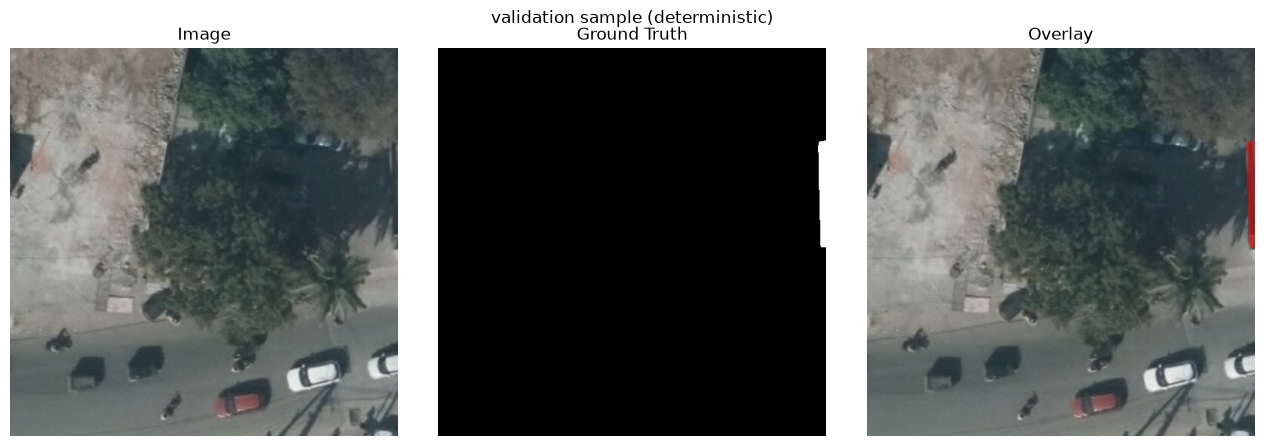

In [13]:
from fp.viz import plot_sample

fig = plot_sample(sample["image"], sample["mask"], config, title="validation sample (deterministic)")

Augmentation is applied identically to image and mask, with nearest-neighbour
interpolation for the mask so labels stay binary.

augmented mask unique values: tensor([0., 1.])


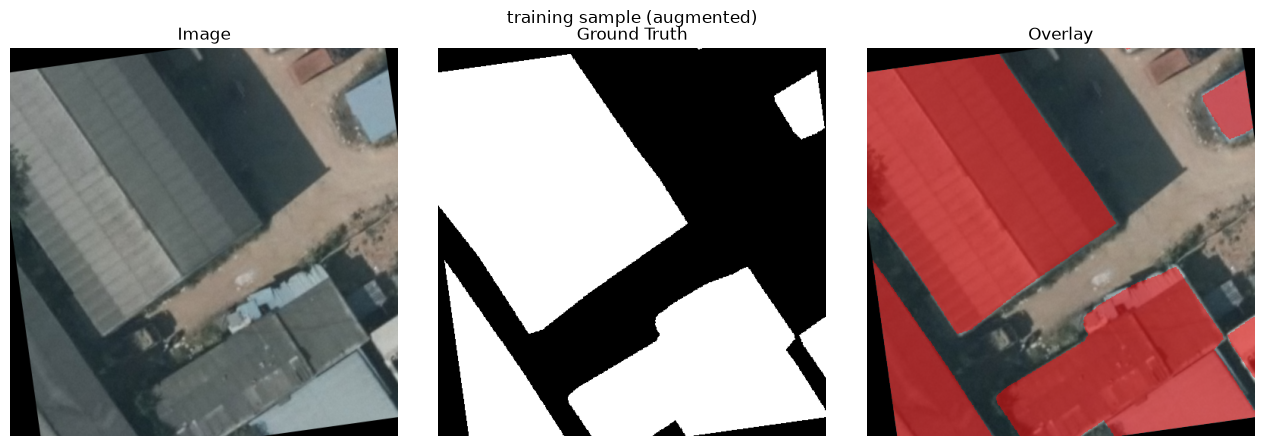

In [14]:
augmented = train_dataset[0]
print("augmented mask unique values:", augmented["mask"].unique())
fig = plot_sample(augmented["image"], augmented["mask"], config, title="training sample (augmented)")

## 6. Build the model: DINOv3 backbone + LoRA + decoder

In [15]:
from fp.model import FootprintModel, parameter_summary

model = FootprintModel(config)
print(parameter_summary(model))
print("decoder:", config["model"]["decoder"], "| LoRA rank:", config["model"]["lora"]["rank"])

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

total parameters:     314,244,225
trainable parameters: 11,114,625
trainable percentage: 3.537%

decoder: dpt | LoRA rank: 16


In [16]:
model.eval()
with torch.no_grad():
    logits = model(sample["image"].unsqueeze(0))
print("output logits shape:", logits.shape)

output logits shape: torch.Size([1, 1, 512, 512])


## 7. Train with PyTorch Lightning

In [ ]:
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from fp.callbacks import PredictionPlotCallback
from fp.config import make_run_dir
from fp.lightning_module import FootprintSegmenter

run_dir = make_run_dir(config)
module = FootprintSegmenter(config)

training_cfg = config["training"]
callbacks = [
    ModelCheckpoint(
        dirpath=run_dir / "checkpoints", filename="best", monitor="val_iou", mode="max", save_last=True
    ),
    PredictionPlotCallback(val_dataset, config, run_dir / "plots"),
]
if training_cfg["early_stopping"]["enabled"]:
    es = training_cfg["early_stopping"]
    callbacks.append(EarlyStopping(monitor=es["monitor"], mode=es["mode"], patience=es["patience"], min_delta=es["min_delta"]))

trainer = L.Trainer(
    max_epochs=training_cfg["max_epochs"],
    precision=training_cfg["precision"],
    accumulate_grad_batches=training_cfg["accumulate_grad_batches"],
    gradient_clip_val=training_cfg["gradient_clip_val"],
    limit_train_batches=training_cfg.get("limit_train_batches", 1.0),
    limit_val_batches=training_cfg.get("limit_val_batches", 1.0),
    callbacks=callbacks,
    logger=CSVLogger(save_dir=run_dir, name="logs", version=""),
)

trainer.fit(module, train_dataloaders=loaders["train"], val_dataloaders=loaders["val"])
best_checkpoint = trainer.checkpoint_callback.best_model_path
print("best checkpoint:", best_checkpoint)

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(limit_train_batches=1.0)` was configured so 100% of the batches per epoch will be used..
`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
You are using a CUDA device ('NVIDIA RTX PRO 4500 Blackwell') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Data_Science\BuildingFootPrints\.venv\Lib\si

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model        │ FootprintModel │  314 M │ train │     0 │
│ 1 │ val_metrics  │ ModuleDict     │      0 │ train │     0 │
│ 2 │ test_metrics │ ModuleDict     │      0 │ train │     0 │
└───┴──────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 11.1 M                                                                                           
Non-trainable params: 303 M                                                                                        
Total params: 314 M                                                                                                
Total estimated model params size (MB): 1,256.977                                                                  
Modules in train mode: 1010                                                                                        
Modules in eval mode: 367                                                                                          
Total FLOPs: 0

Output()

c:\Data_Science\BuildingFootPrints\.venv\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:538: Found 367 
module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is 
intentional, you can ignore this warning.

## 8. Training curves and saved validation plots

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv(run_dir / "logs" / "metrics.csv")
epoch_history = history.groupby("epoch").mean(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
if "val_iou" in epoch_history:
    axes[0].plot(epoch_history.index, epoch_history["val_iou"], marker="o")
    axes[0].set_title("validation IoU")
    axes[0].set_xlabel("epoch")
if "val_loss" in epoch_history:
    axes[1].plot(epoch_history.index, epoch_history["val_loss"], marker="o", color="tab:red")
    axes[1].set_title("validation loss")
    axes[1].set_xlabel("epoch")
fig.tight_layout()

FileNotFoundError: [Errno 2] No such file or directory: 'outputs\\smoke\\logs\\metrics.csv'

In [ ]:
from IPython.display import Image, display

plot_files = sorted((run_dir / "plots").glob("epoch_*.png"))
if plot_files:
    display(Image(filename=str(plot_files[-1])))
else:
    print("no validation plots saved yet")

no validation plots saved yet


## 9. Test evaluation

The test split is used only now, after checkpoint selection on validation `val_iou` —
never during training or early stopping.

In [ ]:
import json

best_module = FootprintSegmenter.load_from_checkpoint(best_checkpoint, config=config)
test_trainer = L.Trainer(logger=False)
test_results = test_trainer.test(best_module, dataloaders=loaders["test"])[0]

(run_dir / "test_metrics.json").write_text(json.dumps(test_results, indent=2))
pd.Series(test_results).to_frame("value")

NameError: name 'best_checkpoint' is not defined

In [ ]:
from fp.viz import plot_predictions

test_dataset = PatchDataset(grid, config, "test", augmented=False)
n_plots = min(config["evaluation"]["num_test_plots"], len(test_dataset))
threshold = config["evaluation"]["threshold"]

best_module.eval()
images, masks, predictions = [], [], []
with torch.no_grad():
    for i in range(n_plots):
        s = test_dataset[i]
        probability = best_module(s["image"].unsqueeze(0)).sigmoid().squeeze(0).squeeze(0)
        images.append(s["image"])
        masks.append(s["mask"])
        predictions.append((probability > threshold).float())

fig = plot_predictions(images, masks, predictions, config, title="test set")
(run_dir / "test_plots").mkdir(parents=True, exist_ok=True)
fig.savefig(run_dir / "test_plots" / "test_predictions.png", dpi=120)

NameError: name 'best_module' is not defined

## 10. Reproducibility artefacts

Everything needed to reproduce this run exactly is under `outputs/<project.name>/`:

In [ ]:
for p in sorted(run_dir.rglob("*")):
    if p.is_file():
        print(p.relative_to(run_dir))

config.yaml
